In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from input_pipeline import preprocess_dataset, mask_dataset, batch_sampler
import xarray as xr
import jax.numpy as jnp
import jax
import chex
import numpy as np
import flax
import rich
import flax.linen as nn
import optax

### Load, Normalization & Masking

In [3]:
ds = xr.load_dataarray('../data/SiC_100x10.nc')
filtered_ds = preprocess_dataset(ds, verbose = True)
masked_ds = mask_dataset(filtered_ds)

Dropped 20 spectra


In [24]:
variables = {
    'params': {
        'median_counts' : filtered_ds.median(dim='spectra').values,
        'wave_number' : filtered_ds.wave_number.values,
    }
}

In [26]:
def median_baseline(params, spectra, wave_number):
    from jax.numpy import interp
    x = interp(wave_number, params['wave_number'], params['median_counts'])
    return spectra - x

In [27]:
test_ds = preprocess_dataset(xr.load_dataarray('../data/SiC+Graphene_8x8.nc'), verbose = True)

Dropped 2 spectra


In [28]:
test_ds.sel(spectra = (0,0))

<xarray.DataArray (wave_number: 1015)>
array([ 0.02934796,  0.06433506,  0.05317375, ...,  0.02893619,
       -0.00947952,  0.01148555])
Coordinates:
  * wave_number  (wave_number) float64 1.279e+03 1.28e+03 ... 2.821e+03
    spectra      object (0, 0)
    X            int64 0
    Y            int64 0

In [30]:
pred = median_baseline(variables['params'], test_ds.sel(spectra = (0,0)).values, test_ds.wave_number.values)

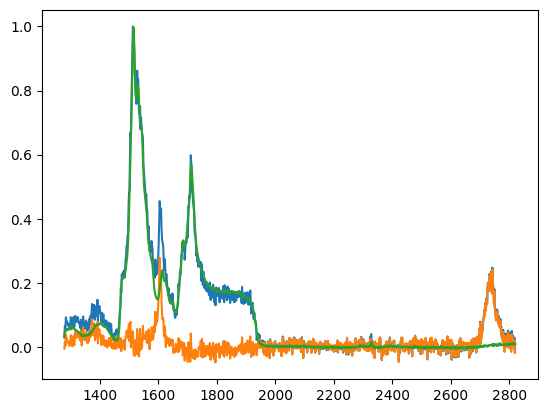

In [34]:
import matplotlib.pyplot as plt
plt.plot(test_ds.wave_number, test_ds.sel(spectra = (0,0)).values)
plt.plot(test_ds.wave_number, pred)
plt.plot(variables['params']['wave_number'], variables['params']['median_counts'])

In [18]:
# Transformer model. See "Formal algorithms for transformers" [arXiv:2207.09238 [cs.LG]] and "On Layer Normalization in the Transformer Architecture" [arXiv:2002.04745 [cs.LG]] and "An introduction to transformers" [arXiv:2304.10557 [cs.LG]].

class LinearProjection(nn.Module):
    """Linear embedding projection"""
    embedding_dim: int

    @nn.compact
    def __call__(self, x):
        x = nn.LayerNorm()(x)
        x = nn.Dense(self.embedding_dim, use_bias=False)(x)
        x = nn.LayerNorm()(x)
        return x
    
def test_LinearProjection():
    """Test LinearProjection"""
    x = np.random.randn(1, 2, 3, 100)
    model = LinearProjection(128)
    variables = model.init(jax.random.PRNGKey(0), x)
    y = model.apply(variables, x)
    chex.assert_shape(y, (1,2, 3, 128))
    chex.assert_shape(variables['params']['Dense_0']['kernel'], (100, 128))
test_LinearProjection()

class FFBlock(nn.Module):
    """Feed-forward block for transformer model"""
    embedding_dim: int
    dropout_rate: float

    @nn.compact
    def __call__(self, x, training: bool):
        x = nn.Dense(4*self.embedding_dim)(x)
        x = nn.relu(x)
        x = nn.Dropout(self.dropout_rate, deterministic = not training)(x)
        x = nn.Dense(self.embedding_dim)(x)
        return x
    
class MLP(nn.Module):
    """Multi-layer perceptron"""
    embedding_dim: int
    num_layers: int
    dropout_rate: float

    @nn.compact
    def __call__(self, x, training: bool):
        for _ in range(self.num_layers):
            x = FFBlock(self.embedding_dim, self.dropout_rate)(x, training = training)
        return x

class TransformerEncoderLayer(nn.Module):
    """Transformer encoder layer"""
    embedding_dim: int
    num_heads: int
    dropout_rate: float

    @nn.compact
    def __call__(self, x, training: bool):
        # Multi-head attention
        x_norm = nn.LayerNorm()(x)
        x_norm = nn.MultiHeadDotProductAttention(
            num_heads = self.num_heads,
            qkv_features = self.embedding_dim,
            dropout_rate = self.dropout_rate
        )(x_norm, deterministic = not training)
        x = x + nn.Dense(self.embedding_dim)(x_norm)
        x = nn.Dropout(self.dropout_rate, deterministic = not training)(x)
        x_norm = nn.LayerNorm()(x)
        x_norm = FFBlock(self.embedding_dim, self.dropout_rate)(x_norm, training = training)
        x = x + nn.Dense(self.embedding_dim)(x_norm)
        return x
    
class SpectraFormer(nn.Module):
    embedding_dim: int
    num_heads: int
    num_layers: int
    dropout_rate: float = 0.1

    @nn.compact
    def __call__(self, counts, wave_number, training: bool = True):
        emb_counts = LinearProjection(self.embedding_dim)(counts)
        emb_wave_number = LinearProjection(self.embedding_dim)(wave_number)
        x = emb_counts + emb_wave_number
        for _ in range(self.num_layers):
            x = TransformerEncoderLayer(self.embedding_dim, self.num_heads, self.dropout_rate)(x, training = training)
        x = nn.LayerNorm()(x)
        x = nn.Dense(1)(x)
        return x

In [10]:
from flax.training import train_state
class TrainState(train_state.TrainState):
  key: jax.Array

In [11]:
@jax.jit
def train_step(state: TrainState, batch, dropout_key):
  dropout_train_key = jax.random.fold_in(key=dropout_key, data=state.step)
  def loss_fn(params):
    pred_spectra = state.apply_fn(
      {'params': params},
      batch['masked_spectra'], batch['wave_number'],
      training=True,
      rngs={'dropout': dropout_train_key}
      )
    loss = optax.squared_error(pred_spectra, batch['spectra']).mean()
    return loss
  grad_fn = jax.value_and_grad(loss_fn)
  loss, grads = grad_fn(state.params)
  state = state.apply_gradients(grads=grads)
  return state, loss

In [12]:
model = SpectraFormer(embedding_dim = 32, num_heads = 4, num_layers = 4)
root_key = jax.random.key(seed=0)
main_key, params_key, dropout_key = jax.random.split(key=root_key, num=3)

dummy_batch = next(batch_sampler(filtered_ds, masked_ds))
variables = model.init(params_key, dummy_batch['masked_spectra'][0], dummy_batch['wave_number'][0], training = False)
params = variables['params']

state = TrainState.create(
  apply_fn=jax.jit(model.apply, static_argnames='training'),
  params=params,
  key=dropout_key,
  tx=optax.adam(1e-4)
)

from tqdm import tqdm
n_epochs = 100
train_loss = []

In [13]:
for epoch in tqdm(range(n_epochs)):
    train_iter = batch_sampler(filtered_ds, masked_ds, batch_size = 16, shuffle = True, drop_last = True, rng_seed = epoch)
    for batch in train_iter:
        state, _loss = train_step(state, batch, dropout_key)
        train_loss.append(_loss.item())

  0%|          | 0/100 [00:00<?, ?it/s]

  6%|▌         | 6/100 [00:25<06:32,  4.18s/it]


KeyboardInterrupt: 

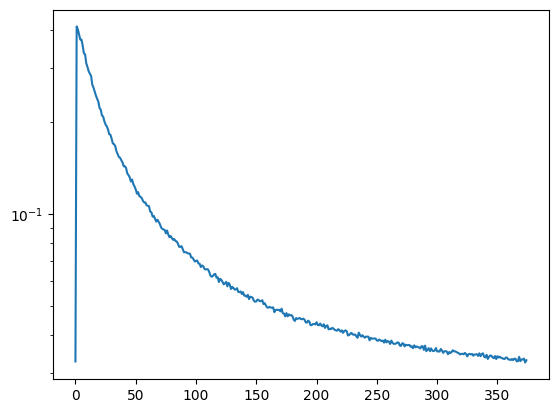

In [14]:
import matplotlib.pyplot as plt
plt.plot(train_loss)
plt.yscale('log')

In [15]:
pred_spectra = state.apply_fn({'params': state.params}, dummy_batch['masked_spectra'][0], dummy_batch['wave_number'], training = False)
true_spectra = dummy_batch['spectra'][0]

In [16]:
pred_spectra

Array([[0.10015126],
       [0.10015126],
       [0.10015126],
       ...,
       [0.10015126],
       [0.10015126],
       [0.10015126]], dtype=float32)

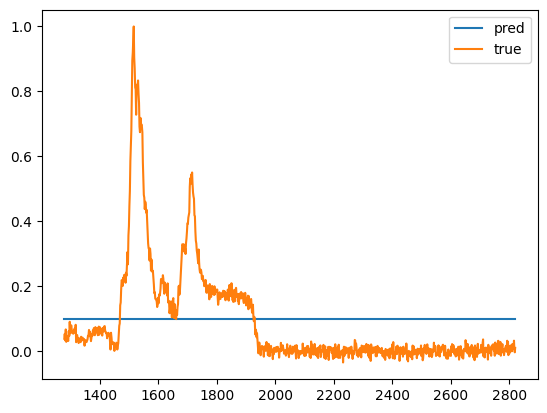

In [17]:
plt.plot(dummy_batch['wave_number'], pred_spectra, label = 'pred')
plt.plot(dummy_batch['wave_number'], true_spectra, label = 'true')
plt.legend()

In [9]:
from time import perf_counter

# Measure throughput at different batch sizes
batch_sizes = [8, 16, 32, 64, 128, 256]

for batch_size in batch_sizes:
    train_iter = batch_sampler(filtered_ds, masked_ds, batch_size = batch_size, shuffle = True, drop_last = True)
    rng = jax.random.PRNGKey(0)
    rng, init_rng = jax.random.split(rng)
    batch = next(train_iter)
    variables = model.init(init_rng, counts = batch['masked_spectra'][0], wave_number = batch['wave_number'][0], training = False)
    # Warmup
    apply_fn = jax.jit(model.apply, static_argnames='training')
    apply_fn(variables, batch['masked_spectra'], batch['wave_number'], training=True, rngs = {'dropout': rng})
    
    # Measure throughput
    times = []
    for batch in train_iter:
        _dt = perf_counter()
        out = apply_fn(variables, batch['masked_spectra'], batch['wave_number'], training=True, rngs = {'dropout': rng})
        _dt = perf_counter() - _dt
        times.append(_dt)
    times = np.array(times)
    print(f"Batch size: {batch_size}, throughput: {batch_size / times.mean():.0f} samples/s")

Batch size: 8, throughput: 18170 samples/s
Batch size: 16, throughput: 29596 samples/s
Batch size: 32, throughput: 17774 samples/s
Batch size: 64, throughput: 16471 samples/s
Batch size: 128, throughput: 13481 samples/s
Batch size: 256, throughput: 19556 samples/s


In [32]:
def print_tree(params):
    for k, v in params.items():#['LinearProjection_1']['Dense_0']['kernel'].shape
        if isinstance(v, dict):
            if 'kernel' in v.keys():
                print(f"{k}: {v['kernel'].shape}")
            else:
                print(k)
                print_tree(v)

In [33]:
print_tree(variables['params'])

LinearProjection_0
LayerNorm_0
Dense_0: (1, 8)
LayerNorm_1
LinearProjection_1
LayerNorm_0
Dense_0: (1, 8)
LayerNorm_1
TransformerEncoderLayer_0
LayerNorm_0
MultiHeadDotProductAttention_0
query: (8, 1, 8)
key: (8, 1, 8)
value: (8, 1, 8)
out: (1, 8, 8)
Dense_0: (8, 8)
LayerNorm_1
FFBlock_0
Dense_0: (8, 32)
Dense_1: (32, 8)
Dense_1: (8, 8)
TransformerEncoderLayer_1
LayerNorm_0
MultiHeadDotProductAttention_0
query: (8, 1, 8)
key: (8, 1, 8)
value: (8, 1, 8)
out: (1, 8, 8)
Dense_0: (8, 8)
LayerNorm_1
FFBlock_0
Dense_0: (8, 32)
Dense_1: (32, 8)
Dense_1: (8, 8)
LayerNorm_0
Dense_0: (8, 1)
